# Basic Julia

David Evans  
2026-03-30

## Why Julia?

### Why Julia?

-   Julia is a high-level, high-performance language for technical
    computing
-   Combines the **ease-of-use** of Python/R with the **speed** of
    C/Fortran
-   Increasingly popular in economics, statistics, and computational
    science

. . .

> **The “Two Language Problem”**
>
> In many fields, researchers prototype in a slow language (Python, R,
> Matlab) then rewrite in a fast language (C, Fortran) for production.
> Julia solves this: one language for both.

### What We’ll Cover

1.  **Primitive data types** — booleans, integers, floats, and strings
2.  **Container types** — arrays, tuples, named tuples, and dictionaries
3.  **Control flow** — `for` loops, comparisons, logical operators, `if`
    statements
4.  **Functions** — defining reusable code with inputs and outputs
5.  **Root solving** — finding CES market equilibria with NonlinearSolve
6.  **Optimization** — CES utility and profit maximization with Optim

. . .

By the end of this lecture you should be comfortable writing simple
Julia programs that store data, loop, make decisions, organize code into
functions, and use packages for root solving and optimization.

# Primitive Data Types

## Booleans

### Booleans

-   There are several basic types of variables in Julia, the most common
    are: boolean, integer, float, complex number.

. . .

-   Booleans are very simple variables that can be in only one of 2
    states: True and False

In [3]:
x = true #Boolean Type
y = 100 < 10 #evaluates the right hand side.  Assigns output to y

false

In [4]:
typeof(y) #Bool means Boolean

Bool

## Integers

### Integers

-   Integer variables are variables x which can be any number
    $x = -\infty,\ldots,-3,-2,-1,0,1,2,3,\ldots,\infty$
    -   For example $0.5$ and $\pi$ are not integers

In [5]:
x = 3
y = 5
x+y

8

In [6]:
typeof(x) #Int64 means integer

Int64

### Integer Division

-   Default produces natural results

In [7]:
x/y

0.6

. . .

-   Can also compute the remainder of integer division using `%`

In [8]:
5%3

2

In [9]:
51%17 #51 is a multiple of 17

0

## Floating Point Numbers

### Floats

-   Real numbers are represented with floats in Julia

In [10]:
Pi = 3.14159265358979323846264
typeof(Pi)

Float64

-   `pi` is also a prestored constant

In [11]:
pi

π = 3.1415926535897...

### Float Arithmetic

-   Multiplication and division work in the standard way

In [12]:
pi * 4

12.566370614359172

In [13]:
pi/3

1.0471975511965976

. . .

-   Can use `a^b` to compute $a^b$

In [14]:
2^4

16

### Ensuring Float Type

If you want to make sure a variable is a float, add a decimal point to
the end

In [15]:
x = 3 #integer
y = 3. #float

3.0

## Strings

### Strings

-   A **string** is a sequence of characters, enclosed in double quotes
-   Single quotes are for individual characters (`Char`)

In [16]:
greeting = "Hello, world!"
typeof(greeting)

String

In [17]:
c = 'A'        # This is a Char, not a String
typeof(c)

Char

### String Operations

-   Concatenate strings with `*` (not `+`!)

In [18]:
first_name = "David"
last_name = "Evans"
first_name * " " * last_name

"David Evans"

. . .

-   Repeat strings with `^`

In [19]:
"ha" ^ 3

"hahaha"

### String Interpolation

-   Embed variables in strings using `$`

In [20]:
name = "David"
age = 39
"My name is $name and I am $age years old."

"My name is David and I am 39 years old."

. . .

-   Use parentheses for expressions

In [21]:
x = 10
"The square of $x is $(x^2)."

"The square of 10 is 100."

### Useful String Functions

In [22]:
s = "Economics is great"
length(s)

18

In [23]:
uppercase(s)

"ECONOMICS IS GREAT"

In [24]:
occursin("great", s)    # Is substring present?

true

In [25]:
replace(s, "great" => "fascinating")

"Economics is fascinating"

In [26]:
split(s)    # Split on whitespace

3-element Vector{SubString{String}}:
 "Economics"
 "is"
 "great"

### Converting Strings and Numbers

-   `parse` converts a string to a number
-   `string` converts a number to a string

In [27]:
parse(Int64, "42")

42

In [28]:
parse(Float64, "3.14")

3.14

In [29]:
string(2.718)

"2.718"

# Container Types

## Overview

### Container Types Overview

**Arrays `[]`**

-   Mutable, ordered by index
-   `[1, 2, 3]`

**Tuples `()`**

-   Immutable, ordered by index
-   `(1, 2, 3)`

**Named Tuples**

-   Immutable, access by name
-   `(a=1, b=2)`

**Dictionaries**

-   Mutable, named keys
-   `Dict("a" => 1)`

## Arrays

### Arrays

-   Sometimes a variable is just a number
-   Other times we want more information associated with that variable
-   In Julia it is possible to combine many elements of different types
    into an array

In [30]:
David = [40,"male",71.5] #square brackets indicate array
typeof(David)

Vector{Any} (alias for Array{Any, 1})

. . .

Note: `Any` means this array can hold any type of object.

### Typed Arrays

We can also make arrays which are of only one type

In [31]:
Davidfloat = [32.1,16.,35]
typeof(Davidfloat)

Vector{Float64} (alias for Array{Float64, 1})

`Davidfloat` only holds floating point numbers. Julia is generally more
efficient if it knows what type of objects variables are.

In [32]:
Davidfloat[2] = "test" # This will error!

MethodError: MethodError: Cannot `convert` an object of type String to an object of type Float64
The function `convert` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  convert(::Type{T}, !Matched::T) where T<:Number
   @ Base number.jl:6
  convert(::Type{T}, !Matched::Number) where T<:Number
   @ Base number.jl:7
  convert(::Type{T}, !Matched::T) where T
   @ Base Base_compiler.jl:133
  ...


### Accessing and Modifying Arrays

-   You can access and change elements of a list using the `[]` operator

In [33]:
David[2]

"male"

. . .

-   You can change elements of the list and append elements to it

In [34]:
David[3] = David[3]/12
push!(David,12) #push! adds an element to the end of an Array
# ! the exclamation point is because push changes David (adds to it)
David

4-element Vector{Any}:
 40
   "male"
  5.958333333333333
 12

### Element Access and Indexes

> **Julia is indexing starts at 1!**
>
> Unlike Python (which starts at 0), Julia arrays start at index 1. This
> is a common source of bugs when switching languages.

-   `L[1]` gives us the first element of array L
-   `L[i]` gives us access to the element at index $i$ of array `L`

. . .

-   Element access also works in reverse: `L[end]` gives access to the
    last element, `L[end-1]` the second to last, etc.

### Array Slicing

-   You can access a slice of the list using `:`
-   `L[1:4]` returns the list `[L[1],L[2],L[3],L[4]]`

In [35]:
print( David[1:3] ) #Could have also used David[1:end-1]

Any[40, "male", 5.958333333333333]

## Tuples

### Tuples

-   Tuples are a list of elements (which are not necessarily of the same
    type) which cannot be changed

In [36]:
d = (39,"male",71.5) #use round brackets to denote tuple
d = 39,"male",71.5 #or no brackets at all
print( typeof(d) ) #note Julia knows what types these elements are

Tuple{Int64, String, Float64}

. . .

-   One property of tuples is that they are **immutable**, meaning they
    can’t be changed

In [37]:
d[1] = 5  # This will error!

MethodError: MethodError: no method matching setindex!(::Tuple{Int64, String, Float64}, ::Int64, ::Int64)
The function `setindex!` exists, but no method is defined for this combination of argument types.

### Unpacking Tuples

-   We can unpack tuples in the following way

In [38]:
integers = (4,5,6)
x,y,z = integers
x

4

In [39]:
z

6

. . .

This can also be done with arrays

In [40]:
x,y,z = David #Stores first 3 elements of David in variables x,y,z
x #first element of David

40

### Named Tuples

-   Named tuples let you access elements by **name** instead of just by
    index
-   Combines the immutability of tuples with additional readability

In [41]:
person = (name="David", age=40, height=71.5)
typeof(person)

@NamedTuple{name::String, age::Int64, height::Float64}

. . .

In [42]:
person.name  # Access by name (preferred)

"David"

In [43]:
person[1]    # Can still access by index

"David"

> **When to Use Named Tuples**
>
> Use named tuples when you want immutable data with meaningful field
> names—–great for returning multiple values from functions!

## Dictionaries

### Dictionaries

-   Dictionaries are like lists except that items are **named** instead
    of numbered

In [44]:
David = Dict("age" => 39, "gender" => "male", "height"=> 71.5)
print( typeof(David) )

Dict{String, Any}

In [45]:
David["age"]

39

### Modifying Dictionaries

-   Can also add to dictionary (unlike named tuples)

In [46]:
David["job"] = "Economist"
David["job"]

"Economist"

. . .

-   `"age"`, `"gender"` and `"height"` are the **keys**
-   The dictionary `David` maps them into the **values** 39, “male”, and
    71.5
-   Useful when dealing with many elements and don’t want to figure out
    what position a variable is in

# Iterating

## For Loops

### For Loops

-   The most basic loop in Julia is the for loop. The basic syntax is:

``` julia
for x in iterable
    code
end
```

which means for each element in an iterable (array, tuple, etc.) repeat
some lines of code, which can depend on the value of `x`

### For Loop Examples

In [47]:
#1:5 is an iterable starting with 1 and ending in 5
for i in 1:5 
    println( i ) #will print i for i running from 1 to 5
end

1
2
3
4
5


In [48]:
#This piece of code prints i^2 from 1:5
for i in 1:5 
    x = i^2
    println( x )
end

1
4
9
16
25


### Unrolling a For Loop

What does the loop actually do? It repeats the body once for each value
of `i`:

In [49]:
# This for loop...
for i in 1:5
    x = i^2
    println(x)
end

1
4
9
16
25


. . .

is equivalent to:

In [50]:
x = 1^2; println(x)
x = 2^2; println(x)
x = 3^2; println(x)
x = 4^2; println(x)
x = 5^2; println(x)

1
4
9
16
25


The loop just saves us from writing the same code over and over!

### Example: Printing Elements

In [51]:
David = [32,"male",71.5]; #the semicolon suppresses output

-   How do you print out all the elements of `David`?

. . .

In [52]:
for element in David
    println( element )
end

32
male
71.5


### Looping Without Indices

-   As we see, Julia by default loops through elements of a list

In [53]:
x_values = [4,2,3]
for x in x_values
    println( x * x )
end

16
4
9


. . .

-   Can also do this, but it is not as easy to read

In [54]:
for i in 1:length(x_values)
    println( x_values[i]*x_values[i] )
end

16
4
9


### Enumerate

> **Best Practice**
>
> Use `enumerate` when you need both the index and the value. It’s
> cleaner than managing a counter variable manually.

In [55]:
letter_list = ['a', 'b', 'c']
for (i, letter) in enumerate(letter_list)
    println("Element $i of letter_list is $letter") #string interpolation
end

Element 1 of letter_list is a
Element 2 of letter_list is b
Element 3 of letter_list is c


### Example: Inner Product

-   How could I take the inner-product of two arrays
    $x = [x_1,\ldots,x_n]$ and $y = [y_1,\ldots,y_n]$?

. . .

In [56]:
x = [3,57,2,1,8,5]
y = [4.3,23,2,47,42,6]
ret = 0.
for i in 1:length(x)
    ret = ret + x[i]*y[i] #alternatively ret += x[i]*y[i]
end
ret

1740.9

### Example: Geometric Sum

How would you compute the sum: $$\sum_{j=0}^{50} \beta^j$$

. . .

In [57]:
β = 0.95 #can use Greek letters: type \beta then hit `tab`
ret = 0.
for j in 0:50
    ret += β^j
end
print( ret )

18.538045469742436

> **Julia Tip**
>
> You can use Greek letters in Julia! Type `\beta` then press `Tab` to
> get β.

# Comparisons and Logical Operators

## Comparisons

### Comparisons

-   Many different types of expressions evaluate to one of the Boolean
    values
-   A common type is comparisons, such as

In [58]:
x,y = 1,2
x < y

true

In [59]:
x > y

false

### Chaining Inequalities

-   We can chain inequalities

In [60]:
1 < 2 < 3

true

In [61]:
1 <= 2 <= 3 > 4

false

### Testing Equality

> **Common Mistake**
>
> Don’t confuse `=` (assignment) with `==` (equality test)!

In [62]:
x = 1 #assignment
x == 2

false

In [63]:
x != 2

true

### Logical AND

-   We can combine expressions using `&&` for “and”

In [64]:
1 < 2 && 'f' in "foo" #true: 1 < 2 AND 'f' is in "foo"

true

In [65]:
1 < 2 && 'g' in "foo" #false: 1 < 2 but 'g' is NOT in "foo"

false

### Logical OR

-   We can combine expressions using `||` for “or”

In [66]:
1 < 2 || 'g' in "foo" #true: 1 < 2 (don't need both for OR)

true

### Logical NOT

-   We can negate expressions using `!` for “not”

In [67]:
!true

false

In [68]:
!!true

true

### Logical Operators Summary

| Expression | Result                                            |
|------------|---------------------------------------------------|
| `P && Q`   | `True` if **both** are `True`, otherwise `False`  |
| `P || Q`   | `False` if **both** are `False`, otherwise `True` |
| `!P`       | Negates `P`                                       |

## If Statements

### If Statement

-   “If” is a special way of evaluating code only if a condition is met

``` julia
if condition
    code
end
```

In [69]:
x = 5
if x > 4
    println( "Yay!" )
end

Yay!


In [70]:
if x < 4
    print( "We did not reach this code, it never ran, how existential" )
end

### If-Else

-   We can use `else` to evaluate code if the condition is not met

In [71]:
x = Int[] #x is an array of ints
for i in 1:10
    if 3<=i<=7
        push!(x,i^2)
    else
        push!(x,i)
    end
end

. . .

In [72]:
println(x)

[1, 2, 9, 16, 25, 36, 49, 8, 9, 10]


### Example: Finding Primes

Find all the primes from 2 to 500

In [73]:
primes = Int[]                  # 1: Initialize empty array of integers
for i in 2:500                  # 2: Loop through candidates 2 to 500
    isprime = true              # 3: Assume i is prime until proven otherwise
    for p in primes             # 4: Check against all known primes
        if i%p == 0             # 5: Does p divide evenly into i?
            isprime = false     # 6: Yes, so i is not prime
        end                     # 7: End if
    end                         # 8: End inner loop
    if isprime                  # 9: If no prime divided i...
        push!(primes, i)        # 10: ...add i to our list of primes
    end                         # 11: End if
end                             # 12: End outer loop

### Finding Primes: Result

In [74]:
primes = Int[]
for i in 2:500
    isprime = true
    for p in primes
        if i%p == 0
            isprime = false
        end
    end
    if isprime
        push!(primes, i)
    end
end
print( primes )

[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97, 101, 103, 107, 109, 113, 127, 131, 137, 139, 149, 151, 157, 163, 167, 173, 179, 181, 191, 193, 197, 199, 211, 223, 227, 229, 233, 239, 241, 251, 257, 263, 269, 271, 277, 281, 283, 293, 307, 311, 313, 317, 331, 337, 347, 349, 353, 359, 367, 373, 379, 383, 389, 397, 401, 409, 419, 421, 431, 433, 439, 443, 449, 457, 461, 463, 467, 479, 487, 491, 499]

# Functions

## Basics

### What Are Functions?

-   A **function** is a reusable piece of code that takes inputs and
    produces outputs
-   For example: $f(x) = x^2$ takes input $x$ and returns $x^2$

. . .

-   We define functions to:
    -   Avoid repeating code
    -   Break complex tasks into simple, testable pieces
    -   Make code easier to read and maintain

### Why Functions Matter

-   Functions in Julia are very flexible:
    -   Any number of functions can be defined in a given file
    -   Any object can be passed as an argument, including other
        functions
    -   Functions can be defined inside other functions
    -   A function can return any kind of object, including functions

### Anonymous (Lambda) Functions

-   The simplest way to define a function is the **arrow syntax**

In [75]:
f = x -> x^2
f(2)

4

In [76]:
f(3)

9

. . .

-   Useful for short, one-off operations (e.g., passing to `map` or
    `sort`)

### The Short-Form Syntax

-   For simple one-line functions with a name, use the **assignment
    form**

In [77]:
g(x) = x^2
g(5)

25

. . .

-   This is identical to the arrow syntax but gives the function a name
    directly

### The `function` Keyword

-   For multi-line functions, use the `function` keyword

In [78]:
function h(x)
    return x^2
end
h(pi)

9.869604401089358

. . .

-   The `return` keyword specifies what the function gives back
-   If omitted, Julia returns the value of the last expression

## Default Arguments and Docstrings

### Default Arguments

-   You can give arguments **default values** so they don’t have to be
    specified every time

In [79]:
function greet(name, greeting="Hello")
    println("$greeting, $(name)!")
end
greet("David")

Hello, David!


In [80]:
greet("David", "Howdy")

Howdy, David!


### Multiple Return Values

-   Functions can return multiple values as a tuple

In [81]:
function divide(a, b)
    quotient = a ÷ b    # integer division
    remainder = a % b
    return quotient, remainder
end
q, r = divide(17, 5)
println("17 ÷ 5 = $q remainder $r")

17 ÷ 5 = 3 remainder 2


### Docstrings

-   You can document functions with a **docstring** (a string before the
    function definition)

In [82]:
"""
    square(x)

Return the square of `x`.
"""
function square(x)
    return x^2
end

square

. . .

-   Access documentation with `?square` in the REPL

## Application: Simulating an AR(1) Process

### The AR(1) Process

-   A key example from time series econometrics:

$$
x_{t} = \rho x_{t-1} + \epsilon_{t} \quad\text{where}\quad \epsilon_{t}\sim N(0,1)
$$

. . .

-   Julia’s `randn()` draws from the standard normal distribution

In [83]:
println(randn())
println(randn())

-0.6878594189388137
-0.06524666271385286


### A Single Step

-   If $x_{t-1} = 5$ and $\rho = 0.8$, one step looks like:

In [84]:
x = 5.0
ρ = 0.8
print(ρ * x + randn())

4.5314524795109765

### Writing the Simulation Function

In [85]:
"""
    simulateAR1(x0, T, ρ=0.8)

Simulate `T` periods of the AR(1) process xₜ = ρ*xₜ₋₁ + εₜ.
"""
function simulateAR1(x0, T, ρ=0.8)
    x = zeros(T)
    x[1] = x0
    for t in 2:T
        x[t] = ρ * x[t-1] + randn()
    end
    return x
end

simulateAR1

-   Uses a default argument for `ρ`
-   Pre-allocates the array with `zeros(T)` for efficiency

### Using the Function

In [86]:
using Plots

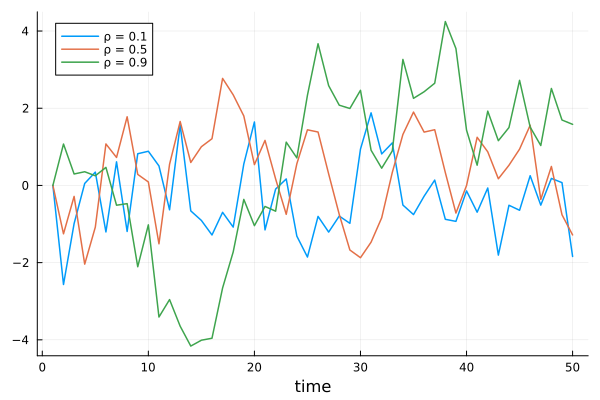

In [87]:
plot()
for ρ in [0.1, 0.5, 0.9]
    plot!(simulateAR1(0., 50, ρ), linewidth=1.5, label="ρ = $ρ")
end
xlabel!("time")

-   Higher $\rho$ means more **persistence** — shocks die out more
    slowly

# Numerical Methods

## Root Solving with NonlinearSolve

### Why Root Solving?

-   Many problems in economics reduce to finding $x^*$ such that
    $f(x^*) = 0$
-   Examples:
    -   **Market equilibrium**: find price where excess demand equals
        zero
    -   **Euler equations**: find optimal consumption satisfying
        first-order conditions
    -   **Fixed points**: find $x^*$ where $g(x^*) - x^* = 0$

. . .

-   The `NonlinearSolve.jl` package provides algorithms for solving
    nonlinear equations

### The NonlinearSolve Interface

In [88]:
using NonlinearSolve

-   Define `f(u, p)` — takes unknowns `u` and parameters `p`
-   Create a problem: `NonlinearProblem(f, u0)`
-   Solve it: `sol = solve(prob)`

. . .

-   The solution is `sol.u`; check `sol.retcode` for convergence status

### Example: CES Market Equilibrium

Constant-elasticity demand and supply:

$$D(p) = A\, p^{-\epsilon_d}, \quad S(p) = B\, p^{\,\epsilon_s}$$

In [89]:
function excess_demand(p, _)
    A, εd = 100.0, 2.0        # demand parameters
    B, εs = 20.0, 1.5         # supply parameters
    D = A * p[1]^(-εd)        # CES demand
    S = B * p[1]^εs           # CES supply
    return [D - S]            # excess demand
end

prob = NonlinearProblem(excess_demand, [1.0])
sol = solve(prob)
sol.u

1-element Vector{Float64}:
 1.583819608766579

. . .

-   Unlike linear models, CES equilibrium has no closed-form solution —
    we need a solver!

### Example: Two-Good CES Equilibrium

Two goods with constant-elasticity demand and cross-price effects
(substitutes):

In [90]:
function two_market(p, _)
    D1 = 100 * p[1]^(-2.0) * p[2]^(0.5)    # good 1 demand
    S1 = 20 * p[1]^(1.5)                     # good 1 supply
    D2 = 80 * p[2]^(-1.5) * p[1]^(0.3)      # good 2 demand
    S2 = 15 * p[2]^(2.0)                     # good 2 supply
    return [D1 - S1, D2 - S2]
end

prob = NonlinearProblem(two_market, [2.0, 2.0])
sol = solve(prob)
sol.u

2-element Vector{Float64}:
 1.7069573735223966
 1.6889575066262879

. . .

-   Raising $p_2$ increases demand for good 1 (substitutes) — prices are
    jointly determined

### NonlinearSolve Tips

> **Working with NonlinearSolve**
>
> -   Always provide a **reasonable initial guess** — bad guesses can
>     lead to wrong roots or convergence failure
> -   Check `sol.retcode` to verify the solver found a solution
> -   Your function must accept two arguments `f(u, p)` — use `_` if you
>     don’t need parameters

## Optimization with Optim

### Why Optimization?

-   Economics is full of optimization problems:
    -   **Consumers** maximize utility subject to a budget constraint
    -   **Firms** maximize profit or minimize cost
    -   **Econometricians** maximize likelihood functions

. . .

-   The `Optim.jl` package provides algorithms for unconstrained
    optimization

### The Optim Interface

In [91]:
using Optim

-   `Optim.jl` **minimizes** by default
-   To **maximize** $f(x)$, minimize $-f(x)$

. . .

-   For scalar functions: `optimize(f, lower, upper)`
-   For multivariate functions: `optimize(f, x0)`

### Example: CES Utility Maximization

A consumer with CES utility over two goods and a budget constraint:

$$U(x_1, x_2) = \bigl(\alpha\, x_1^{\rho} + (1-\alpha)\, x_2^{\rho}\bigr)^{1/\rho}$$

Substituting $x_2 = (I - p_1 x_1)/p_2$ reduces this to a scalar problem:

In [92]:
function neg_utility(x1; α=0.5, ρ=-1.0, p1=1.0, p2=2.0, I=100.0)
    x2 = (I - p1 * x1) / p2
    return -(α * x1^ρ + (1-α) * x2^ρ)^(1/ρ)
end

result = optimize(neg_utility, 1.0, 99.0)
x1_star = Optim.minimizer(result)
x2_star = (100.0 - x1_star) / 2.0
println("x₁ = $(round(x1_star, digits=2)), x₂ = $(round(x2_star, digits=2))")

x₁ = 41.42, x₂ = 29.29


### Example: Short-Run Profit Maximization

A firm with Cobb-Douglas production chooses labor $L$ given fixed
capital $\bar{K}$:

$$\pi(L) = p \cdot A\, \bar{K}^{\alpha}\, L^{1-\alpha} - wL$$

In [93]:
function neg_profit(L; A=1.0, K̄=10.0, α=1/3, p=10.0, w=5.0)
    Y = A * K̄^α * L^(1-α)
    return -(p * Y - w * L)          # negate for minimization
end

result = optimize(neg_profit, 0.1, 1000.0)
L_star = Optim.minimizer(result)
println("Optimal labor: $(round(L_star, digits=2))")
println("Maximum profit: $(round(-Optim.minimum(result), digits=2))")

Optimal labor: 23.7
Maximum profit: 59.26


### Optim Tips

> **Working with Optim**
>
> -   `Optim.jl` **minimizes** — negate your function to maximize
> -   `Optim.minimizer(result)` returns the optimal $x^*$
> -   `Optim.minimum(result)` returns the optimal value $f(x^*)$
> -   For better performance on smooth problems, try
>     `optimize(f, x0, LBFGS())`

# Summary

### Key Takeaways

**Data Types**

-   Booleans: `true`/`false`
-   Integers: `1, 2, 3`
-   Floats: `3.14`
-   Strings: `"hello"`
-   Arrays: `[1, 2, 3]`
-   Tuples: `(1, 2, 3)`
-   Named Tuples: `(a=1, b=2)`
-   Dicts: `Dict("a" => 1)`

**Control Flow**

-   `for` loops
-   `if`/`else` statements
-   Comparisons: `<`, `>`, `==`
-   Logical: `&&`, `||`, `!`

**Functions**

-   Lambda: `x -> x^2`
-   Short: `f(x) = x^2`
-   Multi-line: `function ... end`
-   Default arguments
-   Multiple return values
-   Docstrings

**Numerical Methods**

-   Root solving: `NonlinearSolve.jl`
-   `NonlinearProblem(f, u0)`
-   Optimization: `Optim.jl`
-   Minimizes by default
-   Negate to maximize